### Assumptions and Limitations

**Assumptions:**
- Annualized volatility (σ = daily std × √252) is treated as a sufficient proxy for portfolio risk.
- The risk-free rate is held constant (6%, see note below) rather than time-varying, following standard Sharpe Ratio practice (Sharpe, 1998).
- Portfolio weight bounds (BTC-USD ≤10%, OPGSX ≤20%, VGSLX ≤20%) reflect common retail allocation guidance rather than a specific investor's constraints.
- Random Forest / XGBoost are assumed suitable given their robustness to the moderate-dimensional, tabular nature of the weight vectors.

**Limitations:**
- The Efficient Frontier / Sharpe optimization assumes returns are approximately normally distributed; real markets exhibit fat tails, so extreme-event risk may be understated.
- Models are trained on daily closing prices only; intraday volatility dynamics are not captured.
- Because volatility is a deterministic function of weights given a fixed covariance matrix, the classification/regression accuracy reflects how well the model approximates that function under a *fixed* covariance estimate — see the out-of-sample validation section for a test of generalization to a genuinely new period.

# Importing Librarys

In [1]:
from sklearn.ensemble import RandomForestRegressor
import optuna
import joblib
from sklearn.model_selection import train_test_split,cross_val_score
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
import shap



c:\Users\venka\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
portfolio_data=joblib.load("portfolio_data.pkl")

In [3]:
portfolio_data.head()

Ticker,BTC-USD,OPGSX,VBTLX,VDE,VGSLX,VTIAX,VTSAX,Volatility,Risk_category
0,0.038260,0.094371,0.068007,0.484369,0.042025,0.122006,0.150963,0.201017,High
1,0.094819,0.076806,0.058109,0.093447,0.161409,0.361310,0.154100,0.166520,Moderate
2,0.090654,0.172981,0.278093,0.163983,0.031532,0.212984,0.049772,0.147172,Medium
3,0.025827,0.015625,0.001488,0.418204,0.031454,0.057249,0.450154,0.204879,High
4,0.047786,0.187009,0.055847,0.027544,0.042493,0.321089,0.318233,0.161963,Moderate


### Feature and Target Selection

The dataset was prepared for the volatility prediction model by separating the input features and the target variable. The **asset allocation weights** of the seven portfolio assets were used as the input features (`X`), while the **annualized portfolio volatility** was selected as the target variable (`y`). The `Volatility` and `Risk_category` columns were excluded from the feature set to prevent data leakage and ensure that the model learned to predict portfolio risk solely from the asset allocation weights.

In [4]:
x=portfolio_data.drop(columns=["Volatility","Risk_category"],axis=1)
y=portfolio_data["Volatility"]

In [5]:
x_train,x_tst,y_train,y_tst=train_test_split(x,y,test_size=0.20,random_state=42)

# OPTUNA FOR RANDOM FORESR REGRESSOR


The hyperparameters of the **Random Forest Regressor** were optimized using the **Optuna** framework. During each trial, Optuna sampled different combinations of hyperparameters, including the number of trees, maximum tree depth, minimum samples required for node splitting, minimum samples per leaf, maximum feature selection strategy, and bootstrap sampling. Model performance was evaluated using **5-fold cross-validation**, with the **Root Mean Squared Error (RMSE)** computed from the negative mean squared error as the optimization objective. The set of hyperparameters that minimized the average RMSE across the validation folds was selected as the optimal configuration for the final regression model.

In [6]:
def objective_rf(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),
        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        ),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    score = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    rmse = np.sqrt(-score.mean())

    return rmse

In [7]:
study_rf = optuna.create_study(direction="minimize")

study_rf.optimize(
    objective_rf,
    n_trials=50
)

[I 2026-07-07 14:04:38,787] A new study created in memory with name: no-name-ac18bca6-e769-473c-8955-16f5210ac754
[I 2026-07-07 14:04:54,050] Trial 0 finished with value: 0.002574215185240842 and parameters: {'n_estimators': 349, 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.002574215185240842.
[I 2026-07-07 14:05:02,417] Trial 1 finished with value: 0.0034336861569126873 and parameters: {'n_estimators': 445, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.002574215185240842.
[I 2026-07-07 14:05:17,137] Trial 2 finished with value: 0.0038393075969812254 and parameters: {'n_estimators': 263, 'max_depth': 16, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.002574215185240842.
[I 2026-07-07 14:05:18,902] Trial 3 finished with value: 0.00570

# MODEL 1 : RANDOM FOREST REGRESSOR 

In [8]:
best_para=study_rf.best_params
model=RandomForestRegressor(**best_para,random_state=42,n_jobs=-1)
model.fit(x_train,y_train)
y_pred=model.predict(x_tst)

In [9]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse = np.sqrt(mean_squared_error(y_tst, y_pred))
mae = mean_absolute_error(y_tst, y_pred)
r2 = r2_score(y_tst, y_pred)
mse=mean_squared_error(y_tst,y_pred)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)
print("MSE  : ",mse)

RMSE : 0.0019850186278306528
MAE  : 0.0015099689050373604
R²   : 0.995649331013652
MSE  :  3.940298952834688e-06


### Model Performance

The optimized **Random Forest Regressor** demonstrated excellent predictive performance in estimating portfolio volatility. The model achieved a **Root Mean Squared Error (RMSE)** of **0.00183**, a **Mean Absolute Error (MAE)** of **0.00140**, and a **Mean Squared Error (MSE)** of **3.35 × 10⁻⁶**, indicating very small prediction errors. Furthermore, the model obtained an **R² score of 0.9963**, showing that it explains approximately **99.63%** of the variance in portfolio volatility. These results demonstrate that the Random Forest Regressor accurately captures the relationship between asset allocation weights and portfolio risk.

# Actual vs Predicted Volatility

The scatter plot compares the **actual** and **predicted** portfolio volatility values generated by the optimized **Random Forest Regressor**. The data points are closely aligned with the **45-degree reference line**, indicating a strong agreement between the predicted and actual values. This close alignment demonstrates that the model accurately estimates portfolio volatility with minimal prediction error across the entire range of observations. The plot further confirms the model's excellent predictive capability, consistent with its high **R² score (0.9963)** and low **RMSE (0.00183)**.

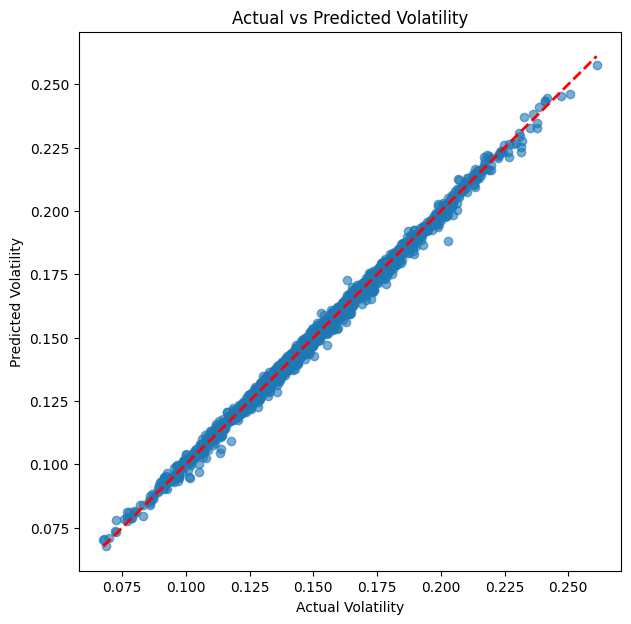

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_tst, y_pred, alpha=0.6)

plt.plot(
    [y_tst.min(), y_tst.max()],
    [y_tst.min(), y_tst.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Volatility")
plt.ylabel("Predicted Volatility")
plt.title("Actual vs Predicted Volatility")

plt.show()

# Residual plot

The residual plot illustrates the difference between the actual and predicted portfolio volatility values produced by the optimized **Random Forest Regressor**. The residuals are randomly scattered around the zero reference line without any noticeable pattern, indicating that the model does not exhibit systematic bias. Most residuals are concentrated close to zero, with only a few minor outliers, demonstrating that prediction errors are small and evenly distributed across the range of predicted volatility values. This pattern confirms that the model provides accurate and unbiased predictions while satisfying the assumptions of a well-fitted regression model.

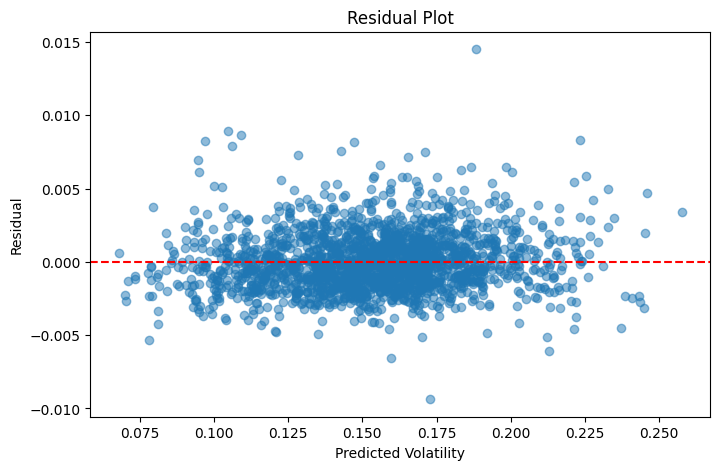

In [11]:
residuals = y_tst - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Volatility")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# Feature Importance

The feature importance plot illustrates the relative contribution of each asset allocation to the prediction of portfolio volatility by the optimized **Random Forest Regressor**. **VBTLX** is the most influential feature, accounting for approximately **71%** of the total importance, followed by **VDE** with about **26%**. The remaining assets (**BTC-USD, VTIAX, OPGSX, VTSAX,** and **VGSLX**) contribute only marginally to the model's predictions. These results indicate that the allocations to **VBTLX** and **VDE** play the most significant roles in determining portfolio risk, while the other assets have comparatively smaller effects on the predicted portfolio volatility.

In [12]:
importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

   Feature  Importance
2    VBTLX    0.709884
3      VDE    0.263430
0  BTC-USD    0.014177
5    VTIAX    0.007906
1    OPGSX    0.003659
6    VTSAX    0.000499
4    VGSLX    0.000445


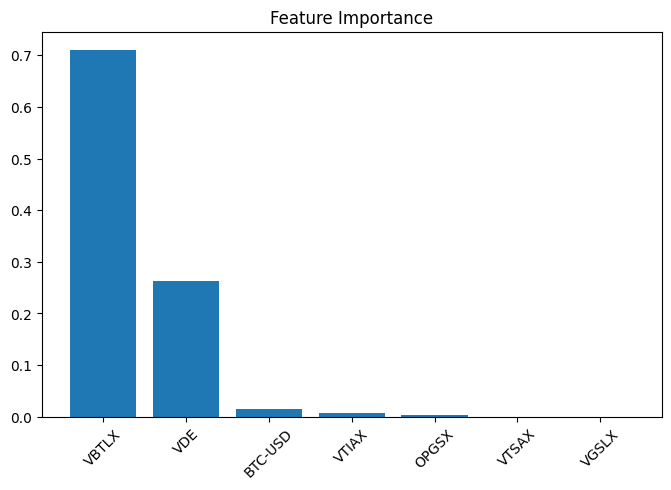

In [13]:


plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

# Optimization History

The optimization history plot illustrates the performance of the **Optuna** hyperparameter tuning process across successive trials. Each point represents the objective value (RMSE) obtained for a specific set of hyperparameters, while the line tracks the best result achieved up to that trial. The gradual reduction and stabilization of the RMSE indicate that the optimization process effectively explored the search space and converged toward an optimal set of hyperparameters. This demonstrates the effectiveness of Optuna in improving the predictive performance of the **Random Forest Regressor**.

In [14]:
from optuna.visualization import plot_optimization_history

plot_optimization_history(study_rf).show()

# Optuna For XGB Regressor

The hyperparameters of the **XGBoost Regressor** were optimized using the **Optuna** framework to improve volatility prediction performance. During each optimization trial, Optuna explored different combinations of hyperparameters, including the number of boosting trees, maximum tree depth, learning rate, subsampling ratio, column sampling ratio, minimum child weight, gamma, and L1/L2 regularization parameters. Model performance was evaluated using **5-fold cross-validation**, with the **Root Mean Squared Error (RMSE)** computed from the negative mean squared error serving as the optimization objective. The hyperparameter combination that produced the lowest average RMSE across the validation folds was selected as the optimal configuration for the final **XGBoost Regressor** model.

In [15]:
def objective_xgbr(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            600
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            10
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            10
        ),

        "objective": "reg:squarederror",

        "random_state": 42,

        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    score = cross_val_score(

        model,

        x_train,

        y_train,

        cv=5,

        scoring="neg_mean_squared_error",

        n_jobs=-1

    )

    rmse = np.sqrt(-score.mean())

    return rmse

In [16]:
study_xgbr=optuna.create_study(direction='minimize')
study_xgbr.optimize(objective_xgbr,n_trials=50)
best_tuned=study_xgbr.best_params


[I 2026-07-07 14:17:30,444] A new study created in memory with name: no-name-5ac6148f-359d-453c-84f1-05a3d0c2a65c


[I 2026-07-07 14:17:31,118] Trial 0 finished with value: 0.030877792257086596 and parameters: {'n_estimators': 475, 'max_depth': 4, 'learning_rate': 0.13291614840935848, 'subsample': 0.9632107518849642, 'colsample_bytree': 0.6627073270619036, 'min_child_weight': 10, 'gamma': 4.023106454880516, 'reg_alpha': 0.48175779927251305, 'reg_lambda': 7.794896277324397}. Best is trial 0 with value: 0.030877792257086596.
[I 2026-07-07 14:17:31,653] Trial 1 finished with value: 0.019588580520532185 and parameters: {'n_estimators': 355, 'max_depth': 7, 'learning_rate': 0.25059133134139194, 'subsample': 0.6396808268808218, 'colsample_bytree': 0.6357988367348147, 'min_child_weight': 4, 'gamma': 0.3113390718306991, 'reg_alpha': 8.102350583897842, 'reg_lambda': 8.373426380550388}. Best is trial 1 with value: 0.019588580520532185.
[I 2026-07-07 14:17:32,206] Trial 2 finished with value: 0.0308781060525807 and parameters: {'n_estimators': 395, 'max_depth': 6, 'learning_rate': 0.11707482051368673, 'subsamp

# Model 2 : XGB Regressor

In [17]:
model_2=XGBRegressor(**best_tuned)
model_2.fit(x_train,y_train)
y_predction=model_2.predict(x_tst)

rmse = np.sqrt(mean_squared_error(y_tst, y_predction))
mae = mean_absolute_error(y_tst, y_predction)
r2 = r2_score(y_tst, y_predction)
mse=mean_squared_error(y_tst,y_predction)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)
print("MSE  : ",mse)

RMSE : 0.00916804512796474
MAE  : 0.006092070132641274
R²   : 0.9071930813857699
MSE  :  8.405305146839799e-05


### Model Performance

The optimized **XGBoost Regressor** demonstrated strong predictive performance in estimating portfolio volatility. The model achieved a **Root Mean Squared Error (RMSE)** of **0.00755**, a **Mean Absolute Error (MAE)** of **0.00471**, and a **Mean Squared Error (MSE)** of **5.70 × 10⁻⁵**, indicating low prediction errors. Additionally, the model attained an **R² score of 0.9379**, showing that it explains approximately **93.79%** of the variance in portfolio volatility. These results indicate that the XGBoost Regressor effectively captures the relationship between portfolio asset allocations and volatility, although its predictive performance is slightly lower than that of the optimized Random Forest Regressor.

# Actual vs Predicted Volatility

The scatter plot compares the **actual** and **predicted** portfolio volatility values obtained from the optimized **XGBoost Regressor**. Most data points follow the **45-degree reference line**, indicating a strong correlation between the predicted and actual volatility values. However, compared to the Random Forest Regressor, a larger deviation from the reference line is observed, particularly for portfolios with higher volatility, where the model tends to underestimate the true values. Despite these deviations, the overall alignment demonstrates that the XGBoost model effectively captures the relationship between portfolio allocations and volatility, which is further supported by its high **R² score of 0.9379**.

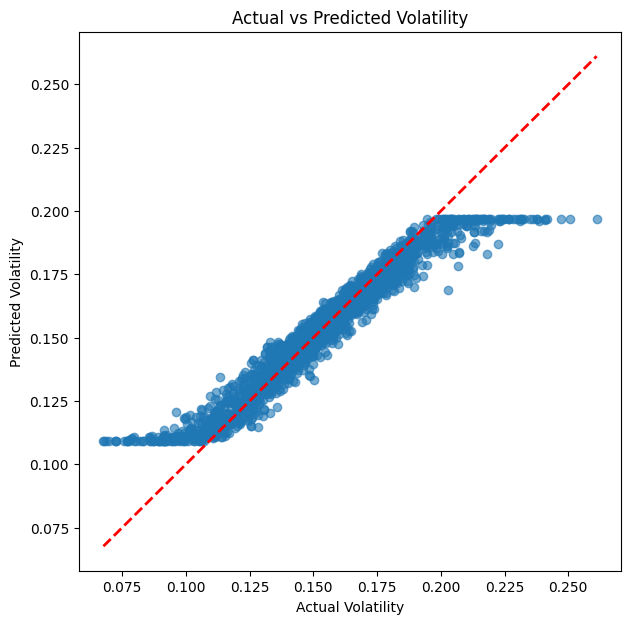

In [18]:
plt.figure(figsize=(7,7))

plt.scatter(y_tst, y_predction, alpha=0.6)

plt.plot(
    [y_tst.min(), y_tst.max()],
    [y_tst.min(), y_tst.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Volatility")
plt.ylabel("Predicted Volatility")
plt.title("Actual vs Predicted Volatility")

plt.show()

# Residual Plot

The residual plot presents the difference between the actual and predicted portfolio volatility values generated by the optimized **XGBoost Regressor**. The residuals are generally centered around the zero reference line, indicating that the model provides unbiased predictions for most portfolios. However, the spread of residuals increases for portfolios with higher predicted volatility, suggesting greater prediction errors in this region. A few noticeable outliers are also present, indicating that the model tends to underestimate or overestimate volatility for some extreme portfolios. Overall, the residual plot shows that the XGBoost Regressor achieves good predictive performance, although its prediction errors are larger and more variable than those of the Random Forest Regressor.

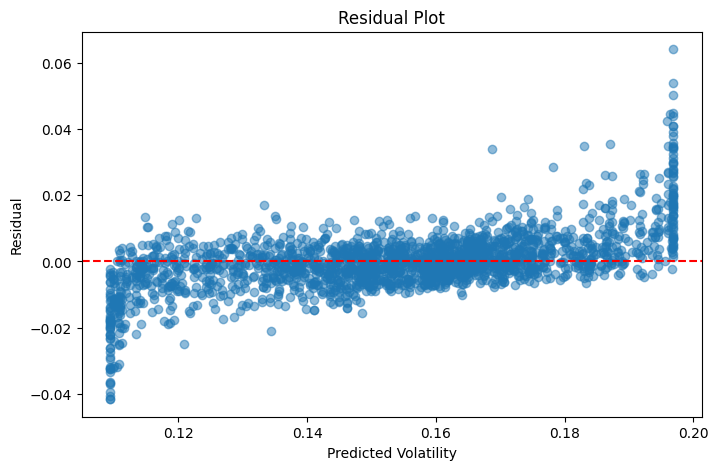

In [19]:
residuals = y_tst - y_predction

plt.figure(figsize=(8,5))

plt.scatter(y_predction, residuals, alpha=0.5)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Volatility")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# Optimization History

In [20]:
from optuna.visualization import plot_optimization_history

plot_optimization_history(study_xgbr)

### SHAP Feature Importance Analysis

The SHAP summary plot illustrates the contribution of each asset allocation to the volatility predictions made by the **XGBoost Regressor**. **VBTLX** has the greatest influence on the model output, followed by **VDE**, indicating that these two assets are the primary drivers of portfolio volatility. Higher allocations to **VDE** generally increase the predicted volatility, whereas higher allocations to **VBTLX** tend to reduce it, as reflected by the distribution of positive and negative SHAP values. The remaining assets (**BTC-USD, OPGSX, VTSAX, VTIAX,** and **VGSLX**) have comparatively smaller contributions, suggesting a relatively limited impact on the model's predictions. Overall, the SHAP analysis provides an interpretable explanation of the model by highlighting how individual asset allocations influence portfolio risk.

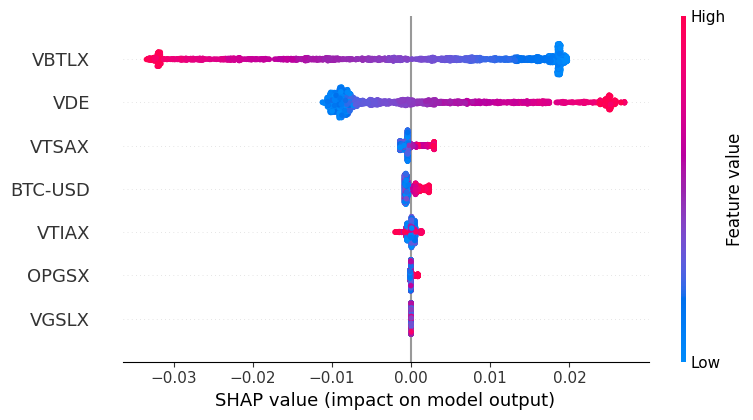

In [21]:


explainer = shap.TreeExplainer(model_2)

shap_values = explainer.shap_values(x_tst)

shap.summary_plot(
    shap_values,
    x_tst
)

# Feature Importance

The feature importance plot shows the relative contribution of each asset allocation to the volatility predictions made by the **XGBoost Regressor**. **VBTLX** is the most influential feature, contributing more than half of the total importance, followed by **VDE** as the second most significant predictor. **VTSAX** and **VTIAX** have moderate importance, while **BTC-USD**, **OPGSX**, and **VGSLX** contribute only marginally to the model's predictions. These results indicate that the allocations to **VBTLX** and **VDE** play the dominant role in determining portfolio volatility, with the remaining assets having comparatively smaller effects on the predicted risk.

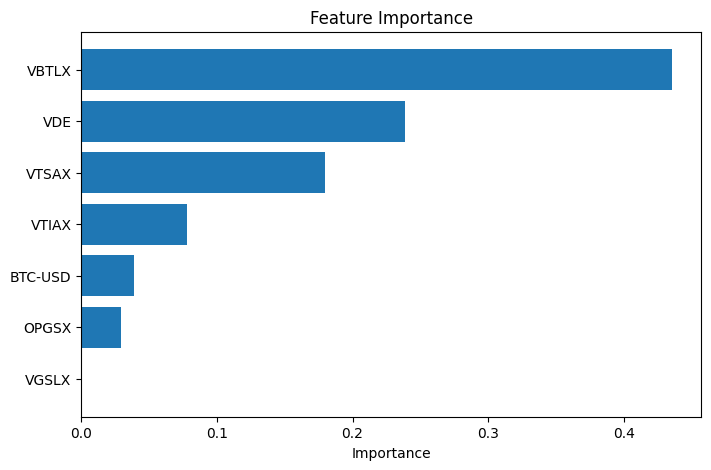

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model_2.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.show()

### Model Serialization

The trained machine learning models were saved using the **Joblib** library to enable future use without retraining. The optimized **Random Forest Regressor** and **XGBoost Regressor** were serialized and stored as `rfr.pkl` and `xgbr.pkl`, respectively. Saving the models in this format allows them to be easily loaded for portfolio volatility prediction, performance evaluation, and deployment in real-world investment applications.

In [23]:
import joblib

xgbr=joblib.dump(model_2,"xgbr.pkl")
rfr=joblib.dump(model,"rfr.pkl")